In [1]:
import numpy as np
import matplotlib.pyplot as plt

import lightkurve  as lk

# import k2sc
# from k2sc.standalone import k2sc_lc

from astropy.io import fits

# %pylab inline --no-import-all
# matplotlib.rcParams['image.origin'] = 'lower'
# matplotlib.rcParams['figure.figsize']=(10.0,10.0)    #(6.0,4.0)
# matplotlib.rcParams['font.size']=16              #10 
# matplotlib.rcParams['savefig.dpi']= 300             #72 
# colours = mpl.rcParams['axes.prop_cycle'].by_key()['color']

import warnings
warnings.filterwarnings('ignore')

print(lk.__version__)
# print(k2sc.__version__)

%matplotlib widget

2.4.2


In [2]:
# lc = lk.search_lightcurve('EPIC 212300977')[1].download()
# lc = lc.remove_nans()
# lc = lc[lc.quality==0]

# files = sorted(glob.glob(lightkurve_file_folder + '*/*.fits.gz'))

# for file in tqdm(files, desc='Reading TPFs'):
#     tpf = lk.read(file, quality_bitmask = 'none')
#     test_case.append(tpf)

In [3]:
tpf = lk.search_targetpixelfile('EPIC 212300977', mission = 'K2')[1].download()

# tpf.hdu[0].header

# # tpf = lk.KeplerTargetPixelFile.from_archive(212300977) # WASP-55
lc = tpf.to_lightcurve() # load some data either as a tpf or just straight up as a lightcurve
lc = lc.remove_nans() # don't know why the quality flags are weird

# # lc.primary_header = tpf.hdu[0].header
# # lc.data_header = tpf.hdu[1].header
# lc.pos_corr1 = tpf.hdu[1].data['POS_CORR1'][tpf.quality_mask]
# lc.pos_corr2 = tpf.hdu[1].data['POS_CORR2'][tpf.quality_mask]

# # # now the magic happens
# # lc.__class__ = k2sc_lc
# lc.k2sc()

lc

time,flux,flux_err,centroid_col,centroid_row,cadenceno,quality
,electron / s,electron / s,pix,pix,,
Time,float32,float32,float64,float64,int32,int32
2384.4634632719535,230043.125,13.946138381958008,886.030940956277,560.8777486597229,111362,524288
2384.483895616526,230317.703125,13.952842712402344,886.00899534779,560.8775388234794,111363,0
2384.5043280606405,230478.875,13.955907821655273,885.9886784844024,560.8781705046481,111364,0
2384.5247603038224,230627.96875,13.96065616607666,885.9695515908205,560.8777685690678,111365,0
2384.5451926469977,230750.25,13.964234352111816,885.9529313070261,560.8782360746592,111366,0
2384.56562508925,230845.28125,13.964629173278809,885.9363798047095,560.8771654372953,111367,0
2384.5860573315003,230948.265625,13.96729564666748,885.9196185385666,560.8759294869158,111368,0
2384.6064896732787,230981.25,13.968029022216797,885.906243315183,560.8744945437539,111369,0


In [4]:
from temp_test_k2sc import k2sc_lc

targetid = lc.targetid
time = lc.time.value
flux = lc.flux.value
flux_err = lc.flux_err.value
xs = tpf.hdu[1].data['POS_CORR1'][tpf.quality_mask]
ys = tpf.hdu[1].data['POS_CORR2'][tpf.quality_mask]
quality = lc.quality
campaign = lc.campaign
cadenceno = lc.cadenceno
hdu = tpf.hdu


data_su = k2sc_lc(targetid, time, flux, flux_err, xs, ys, quality, campaign, cadenceno, hdu)
data = data_su.k2sc()

# targetid, time, flux, flux_err, xs, ys, quality, campaign, cadenceno, hdu)


Using default splits [2390, 2428] for campaign 6
Starting initial outlier detection
  Flagged 117 ( 3.3%) outliers.
Starting Lomb-Scargle period search
  Using SqrExp position kernel
  No strong periodicity found, using a basic kernel
Starting global hyperparameter optimisation using DE


  4%|▍         | 6/150 [05:37<2:14:49, 56.18s/it, -ln(L)=-5206.6]


  DE finished in 337 seconds
  DE minimum found at: [-4.545  0.067 -2.638 11.326 12.151 -3.671]
  DE -ln(L) -5206.6
Starting local hyperparameter optimisation
  Local minimum found at: [-4.499  0.053 -2.885 12.706 28.538 -3.688]
Starting final outlier detection
     45 too high
    132 too low
      0 not finite
Computing time and position trends


/Users/zgl12/.local/lib/python3.11/site-packages/K2SC-1.0.2.2-py3.11.egg/k2sc/cdpp.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)


  CDPP - raw - 14548.182
  CDPP - position component removed - 142.622
  CDPP - full reduction - 142.376
Detrending time 439.28517985343933


In [8]:
data

array([229389.1790275 , 229356.52503649, 229203.2087036 , ...,
       229229.03848248, 229251.60918651, 228940.78327486])

/Users/zgl12/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backends is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
/Users/zgl12/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
/Users/zgl12/anaconda3/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


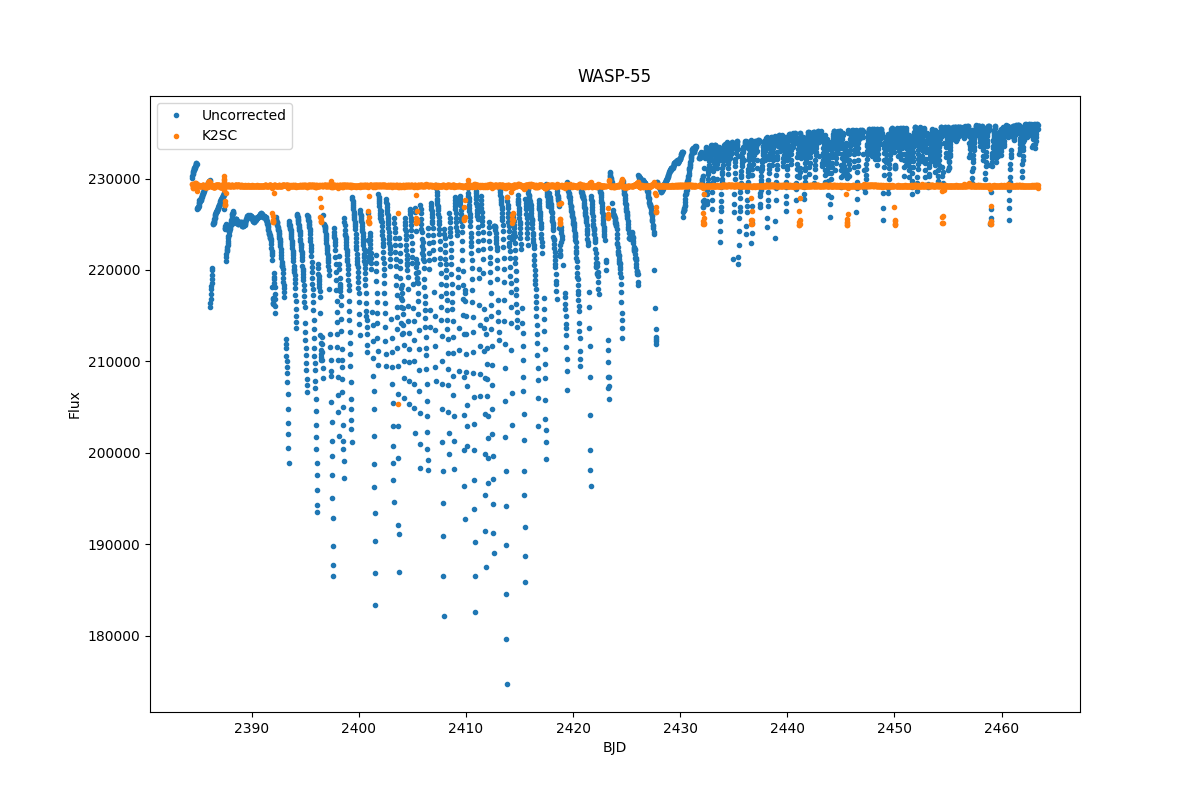

In [12]:
import matplotlib.pyplot as plt

%matplotlib widget

plt.figure(figsize=(12.0,8.0))
plt.plot(time, flux,'.',label="Uncorrected")
# detrended = data.corr_flux-data.tr_time + np.nanmedian(data.tr_time)
plt.plot(time, data,'.',label="K2SC")
plt.legend()
plt.xlabel('BJD')
plt.ylabel('Flux')
plt.title('WASP-55',y=1.01)
plt.show()

In [ ]:
lc
# 886.030940956277	560.8777486597229	

# pos_corrs
# flux
# time

In [ ]:
fig = plt.figure(figsize=(12.0,8.0))
plt.plot(lc.time.value,lc.flux.value,'.',label="Uncorrected")
detrended = lc.corr_flux-lc.tr_time + np.nanmedian(lc.tr_time)
plt.plot(lc.time.value,detrended.value,'.',label="K2SC")
plt.legend()
plt.xlabel('BJD')
plt.ylabel('Flux')
plt.title('WASP-55',y=1.01)
plt.show()

In [ ]:
extras = {'CORR_FLUX':lc.corr_flux.value,
          'TR_TIME':lc.tr_time.value,
          'TR_POSITION':lc.tr_position.value}
# out = lc.to_fits(extra_data=extras,path='test.fits',overwrite=True)

In [ ]:
"""Contains the K2Data class for working with K2 datasets with 1..n flux and error
arrays (using different aperture size, etc.)

"""
from __future__ import division
import numpy as np

from numpy import array, atleast_2d, zeros, ones, ones_like, argmax, all, isfinite, tile, extract, zeros_like
# from scipy.ndimage import binary_dilation, binary_erosion
# from scipy.signal import medfilt

# from .ls import fasper
# from .utils import medsig, fold
# from .core import *

class K2Data():
    """Encapsulates the K2 data.

    Encapsulates the K2 data with 1..n flux and flux uncertainty arrays. Separate
    flux and uncertainty arrays can correspond to different aperture sizes, etc.

    Notes
    -----
    We remove the cadences where either time, x, or y is nan since input nans screw 
    up the GP fitting and reduction. This must be accounted for when saving the data.

    Parameters
    ----------
    epic    : int
              EPIC number of the star
    time    : array_like
              ndarray or list containing the time values
    cadence : array_like
              ndarray or list containing the cadence values
    quality : array_like
              ndarray or list containing the quality values
    fluxes  : array_like
              a list, multiple lists, or [nsets,npoints] ndarray of flux values
    errors  : array_like
              a list, multiple lists, or [nsets,npoints] ndarray of flux values
    x       : array_like
              ndarray or list of x values
    y       : array_like
              ndarray or list of y values

    Attributes
    ----------
    nsets       : int
                  Number of datasets
    npoints     : int
                  Number of datapoints
    is_periodic : bool
                  Does the flux show clear periodic variability
    ls_period   : float
                  Period of the strongest periodic variability detected
    ls_power    : float
                  Lomb-Scargle power of the strongest periodic variability detected
    """
    
    def __init__(self, epic, time, cadence, quality, fluxes, errors, x, y, primary_header=None, data_header=None, campaign=None):
        self.epic = epic
        self.campaign = campaign
        self.nanmask = nm = isfinite(time) & isfinite(x) & isfinite(y)
        self.time = extract(nm, time)
        self.cadence =  extract(nm, cadence)
        self.quality =  extract(nm, quality).astype(np.int32)
        self.fluxes = atleast_2d(fluxes)[:,nm]
        self.errors = atleast_2d(errors)[:,nm]
        self.x = extract(nm,x)
        self.y = extract(nm,y)
        self.primary_header = primary_header
        self.data_header = data_header

        self.nsets   = self.fluxes.shape[0]
        self.npoints = self.fluxes.shape[1]

        self.is_periodic = False
        self.ls_period = None
        self.ls_power = None

        qmask = all(isfinite(self.fluxes),0) & (self.quality==0)
        self.mflags   = zeros([self.nsets, self.npoints], np.uint8)
        # self.mflags[:,~qmask] |= M_QUALITY


    # def mask_periodic_signal(self, center, period, duration):
        # self.pmask = np.abs(fold(self.time, period, center, shift=0.5) - 0.5)*period > 0.5*duration
        # self.mflags[:,~self.pmask] |= M_PERIODIC

    #def __str__(self):
    #    return str(id(self))